# Проверка гипотезы о мобильности и зарплатных ожиданиях

Проверяем гипотезу:

**"Мобильные соискатели в среднем имеют более высокие зарплатные ожидания"**.

Под мобильными будем понимать соискателей, у которых выполнено хотя бы одно из условий:
- `business_trips == 1` — есть готовность к командировкам;
- `relocation == 1` — есть готовность к переезду;
- `schedule_type_1 == 1` — есть желание работать вахтовым методом.

Для проверки используем **односторонний двухвыборочный t-критерий Уэльча**.

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

## 1. Загрузка очищенного датасета

Используем уже подготовленный файл `dataset_cleaned.csv`, полученный в ноутбуке очистки данных.

In [2]:
df = pd.read_csv("dataset_cleaned.csv")

for col in ["salary", "business_trips", "relocation", "schedule_type_1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["is_mobile"] = (
    df["business_trips"].eq(1)
    | df["relocation"].eq(1)
    | df["schedule_type_1"].eq(1)
)

test_df = df[["salary", "business_trips", "relocation", "schedule_type_1", "is_mobile"]].dropna(subset=["salary"]).copy()

print("Размер очищенного датасета:", df.shape)
print("Размер выборки для проверки гипотезы:", test_df.shape)

Размер очищенного датасета: (43227, 67)
Размер выборки для проверки гипотезы: (43227, 5)


## 2. Формирование групп

- `mobile` — мобильные соискатели;
- `non_mobile` — остальные соискатели.

Если признак мобильности не равен 1 ни по одному из трёх полей, соискатель относится к группе `non_mobile`.

In [3]:
mobile = test_df.loc[test_df["is_mobile"], "salary"]
non_mobile = test_df.loc[~test_df["is_mobile"], "salary"]

group_summary = (
    test_df.groupby("is_mobile")["salary"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(index={False: "non_mobile", True: "mobile"})
)

group_summary.round(2)

,count,mean,median,std,min,max
is_mobile,,,,,,
non_mobile,40597,24361.88,20000.0,12525.20,6500,350000
mobile,2630,39859.84,30000.0,26733.67,7000,400000


## 3. Формулировка гипотез

Обозначим:
- $\mu_{mobile}$ — среднее зарплатное ожидание мобильных соискателей;
- $\mu_{non\_mobile}$ — среднее зарплатное ожидание немобильных соискателей.

Тогда проверяем:

- $H_0$: $\mu_{mobile} \leq \mu_{non\_mobile}$
- $H_1$: $\mu_{mobile} > \mu_{non\_mobile}$

Это односторонняя альтернатива (`greater`).

## 4. Реализация Welch t-test

В текущем окружении нет `scipy`, поэтому ниже реализован расчёт статистики Уэльча и p-value вручную.

Используем формулы:

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{s_1^2/n_1 + s_2^2/n_2}}
$$

$$
\nu = \frac{(s_1^2/n_1 + s_2^2/n_2)^2}{(s_1^2/n_1)^2/(n_1-1) + (s_2^2/n_2)^2/(n_2-1)}
$$

где $\nu$ — число степеней свободы по формуле Уэльча-Саттертуэйта.

In [4]:
def betacf(a, b, x, max_iter=200, eps=3e-14):
    qab = a + b
    qap = a + 1.0
    qam = a - 1.0
    c = 1.0
    d = 1.0 - qab * x / qap
    if abs(d) < 1e-300:
        d = 1e-300
    d = 1.0 / d
    h = d

    for m in range(1, max_iter + 1):
        m2 = 2 * m

        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d
        if abs(d) < 1e-300:
            d = 1e-300
        c = 1.0 + aa / c
        if abs(c) < 1e-300:
            c = 1e-300
        d = 1.0 / d
        h *= d * c

        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d
        if abs(d) < 1e-300:
            d = 1e-300
        c = 1.0 + aa / c
        if abs(c) < 1e-300:
            c = 1e-300
        d = 1.0 / d
        delta = d * c
        h *= delta

        if abs(delta - 1.0) < eps:
            break

    return h


def regularized_incomplete_beta(a, b, x):
    if x <= 0.0:
        return 0.0
    if x >= 1.0:
        return 1.0

    ln_beta = math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
    bt = math.exp(a * math.log(x) + b * math.log(1.0 - x) - ln_beta)

    if x < (a + 1.0) / (a + b + 2.0):
        return bt * betacf(a, b, x) / a

    return 1.0 - bt * betacf(b, a, 1.0 - x) / b


def student_t_cdf(t, nu):
    if t == 0:
        return 0.5

    x = nu / (nu + t * t)
    ib = regularized_incomplete_beta(nu / 2.0, 0.5, x)

    if t > 0:
        return 1.0 - 0.5 * ib

    return 0.5 * ib


def welch_ttest_greater(sample_a, sample_b):
    sample_a = pd.Series(sample_a).dropna().astype(float)
    sample_b = pd.Series(sample_b).dropna().astype(float)

    n_a = sample_a.shape[0]
    n_b = sample_b.shape[0]
    mean_a = sample_a.mean()
    mean_b = sample_b.mean()
    var_a = sample_a.var(ddof=1)
    var_b = sample_b.var(ddof=1)

    se = math.sqrt(var_a / n_a + var_b / n_b)
    t_stat = (mean_a - mean_b) / se
    df_welch = (var_a / n_a + var_b / n_b) ** 2 / (
        ((var_a / n_a) ** 2) / (n_a - 1) + ((var_b / n_b) ** 2) / (n_b - 1)
    )

    p_value = 1.0 - student_t_cdf(t_stat, df_welch)

    return {
        "n_mobile": n_a,
        "n_non_mobile": n_b,
        "mean_mobile": mean_a,
        "mean_non_mobile": mean_b,
        "mean_diff": mean_a - mean_b,
        "t_stat": t_stat,
        "df": df_welch,
        "p_value": p_value,
    }

In [5]:
results = welch_ttest_greater(mobile, non_mobile)
alpha = 0.05

results_table = pd.Series(results).to_frame("value")
results_table.loc["alpha"] = alpha
results_table

,value
n_mobile,2630.000000
n_non_mobile,40597.000000
mean_mobile,39859.842586
mean_non_mobile,24361.880779
mean_diff,15497.961806
t_stat,29.520767
df,2704.267407
p_value,0.000000
alpha,0.050000


In [6]:
p_value = results["p_value"]

if p_value == 0.0:
    p_value_text = "0.0 из-за машинного округления; фактически p-value крайне мало"
else:
    p_value_text = f"{p_value:.6e}"

print(f"Средняя зарплата mobile: {results['mean_mobile']:.2f}")
print(f"Средняя зарплата non_mobile: {results['mean_non_mobile']:.2f}")
print(f"Разница средних: {results['mean_diff']:.2f}")
print(f"t-статистика Уэльча: {results['t_stat']:.4f}")
print(f"Степени свободы: {results['df']:.4f}")
print(f"Одностороннее p-value: {p_value_text}")

if p_value < alpha:
    print("Вывод: отвергаем H0 на уровне значимости 0.05.")
    print("Есть статистически значимые основания считать, что мобильные соискатели в среднем ожидают более высокую зарплату.")
else:
    print("Вывод: не отвергаем H0 на уровне значимости 0.05.")
    print("Недостаточно оснований утверждать, что мобильные соискатели в среднем ожидают более высокую зарплату.")

Средняя зарплата mobile: 39859.84
Средняя зарплата non_mobile: 24361.88
Разница средних: 15497.96
t-статистика Уэльча: 29.5208
Степени свободы: 2704.2674
Одностороннее p-value: 0.0 из-за машинного округления; фактически p-value крайне мало
Вывод: отвергаем H0 на уровне значимости 0.05.
Есть статистически значимые основания считать, что мобильные соискатели в среднем ожидают более высокую зарплату.


## 5. Визуальная проверка различий

Графики не заменяют статистический тест, но помогают увидеть, что распределение зарплат у мобильных соискателей действительно смещено вверх.

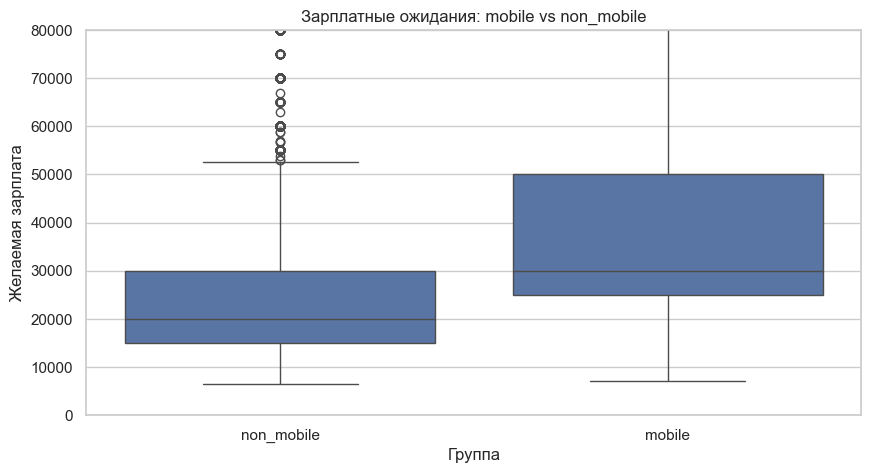

In [7]:
plot_df = test_df.copy()
plot_df["mobility_group"] = np.where(plot_df["is_mobile"], "mobile", "non_mobile")

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x="mobility_group", y="salary")
plt.ylim(0, plot_df["salary"].quantile(0.99))
plt.title("Зарплатные ожидания: mobile vs non_mobile")
plt.xlabel("Группа")
plt.ylabel("Желаемая зарплата")
plt.show()

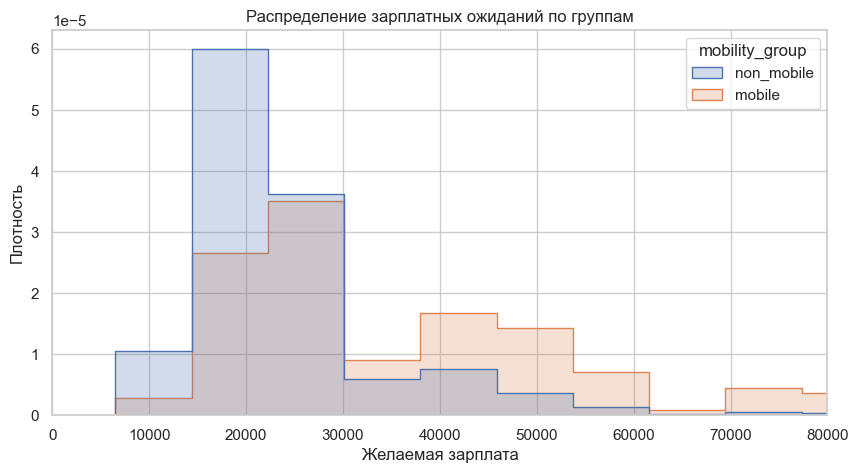

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=plot_df, x="salary", hue="mobility_group", bins=50, stat="density", common_norm=False, element="step")
plt.xlim(0, plot_df["salary"].quantile(0.99))
plt.title("Распределение зарплатных ожиданий по группам")
plt.xlabel("Желаемая зарплата")
plt.ylabel("Плотность")
plt.show()

## 6. Итоговый вывод

По очищенному датасету гипотеза подтверждается: **мобильные соискатели в среднем имеют более высокие зарплатные ожидания**, чем немобильные.

По рассчитанным значениям:
- среднее ожидание у `mobile` заметно выше;
- t-статистика велика и положительна;
- одностороннее p-value значительно меньше 0.05.

Следовательно, нулевая гипотеза отвергается, а альтернативная гипотеза получает статистическую поддержку.